In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class CBCTEncoder(nn.Module):
    def __init__(self, in_channels=1, base_ch=32, emb_dim=512):
        super().__init__()
        self.enc1 = ConvBlock3D(in_channels, base_ch, dropout=0.1)
        self.enc2 = ConvBlock3D(base_ch, base_ch * 2, dropout=0.15)
        self.enc3 = ConvBlock3D(base_ch * 2, base_ch * 4, dropout=0.2)
        self.enc4 = ConvBlock3D(base_ch * 4, base_ch * 8, dropout=0.25)
        self.enc5 = ConvBlock3D(base_ch * 8, base_ch * 16, dropout=0.3)

        self.pool = nn.MaxPool3d(2)
        self.global_pool = nn.AdaptiveAvgPool3d(1)
        self.embedding = nn.Sequential(
            nn.Linear(base_ch * 16, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x = self.pool(x1)
        x2 = self.enc2(x)
        x = self.pool(x2)
        x3 = self.enc3(x)
        x = self.pool(x3)
        x4 = self.enc4(x)
        x = self.pool(x4)
        x5 = self.enc5(x)
        feat = self.global_pool(x5).view(x5.size(0), -1)
        feat = self.embedding(feat)
        return feat

class CBCTClassifier(nn.Module):
    def __init__(self, num_classes, emb_dim=512, base_ch=32):
        super().__init__()
        self.encoder = CBCTEncoder(in_channels=1, base_ch=base_ch, emb_dim=emb_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(emb_dim // 2, num_classes)
        )

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits, features


In [ ]:
BASE_DIR = "MMDENTAL_CODE"
# IMAGE_DIR = os.path.join(BASE_DIR, "MM_preprocessed")
# CSV_PATH  = os.path.join(BASE_DIR, "mmdental_multiclass.csv")
IMAGE_DIR = "MMDental_preprocessed"
CSV_PATH = "mmdental_multiclass_new.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
BATCH_SIZE = 1
EPOCHS = 30
LR = 5e-4

NUM_CLASSES = 8
IMAGE_EMB_DIM = 512
# TEXT_EMB_DIM  = 768

image_model = CBCTClassifier(num_classes=NUM_CLASSES, emb_dim=IMAGE_EMB_DIM)
image_state = torch.load("best_image_model.pth", map_location=DEVICE)
image_model.load_state_dict(image_state)
image_model.to(DEVICE)
image_model.eval()


C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\1122865444.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_state = torch.load("best_image_model.pth", map_loc

CBCTClassifier(
  (encoder): CBCTEncoder(
    (enc1): ConvBlock3D(
      (conv): Sequential(
        (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): LeakyReLU(negative_slope=0.01, inplace=True)
        (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (4): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (5): LeakyReLU(negative_slope=0.01, inplace=True)
      )
    )
    (enc2): ConvBlock3D(
      (conv): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): LeakyReLU(negative_slope=0.01, inplace=True)
        (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (4): InstanceNo

In [ ]:
for p in image_model.encoder.parameters():
    p.requires_grad = False

In [ ]:
TEXT_EMB_DIR = "embeddings_for_multimodal"

X_train_emb = torch.load(os.path.join(TEXT_EMB_DIR, "train_text_embeddings.pt"))
X_val_emb   = torch.load(os.path.join(TEXT_EMB_DIR, "val_text_embeddings.pt"))
y_train = torch.load(os.path.join(TEXT_EMB_DIR, "train_labels.pt"))
y_val   = torch.load(os.path.join(TEXT_EMB_DIR, "val_labels.pt"))

C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\3328128162.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train_emb = torch.load(os.path.join(TEXT_EMB_DIR, "trai

In [ ]:
TEXT_EMB_DIM = X_train_emb.shape[1]
print(TEXT_EMB_DIM)

768


In [ ]:
class MultimodalDataset(Dataset):
    def __init__(self, image_dir, df, text_embeddings, labels):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.text_embeddings = text_embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['Filename']}.pt")
        image = torch.load(img_path).float()
        text_emb = self.text_embeddings[idx]
        label = self.labels[idx]
        return image, text_emb, label

In [ ]:
df = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
train_dataset = MultimodalDataset(IMAGE_DIR, train_df, X_train_emb, y_train)
val_dataset   = MultimodalDataset(IMAGE_DIR, val_df, X_val_emb, y_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class MultimodalClassifier(nn.Module):
    def __init__(self, image_model, text_emb_dim, num_classes):
        super().__init__()
        self.image_model = image_model
        self.text_emb_dim = text_emb_dim
        self.classifier = nn.Sequential(
            nn.Linear(IMAGE_EMB_DIM + text_emb_dim, 256),
            nn.ReLU(),
            # nn.Dropout(0.15),
            nn.Linear(256, num_classes)
        )
    def forward(self, image, text_emb):
        with torch.no_grad():
            _, img_feat = self.image_model(image)
        fused = torch.cat([img_feat, text_emb], dim=1)
        return self.classifier(fused)

In [ ]:
model = MultimodalClassifier(image_model, TEXT_EMB_DIM, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=LR,  weight_decay=1e-5)

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()


In [ ]:
train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_preds, train_labels = [], []
    train_loss = 0.0

    for images, text_embs, labels in train_loader:
        images = images.to(DEVICE)
        text_embs = text_embs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images, text_embs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss /= len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0.0
    with torch.no_grad():
        for images, text_embs, labels in val_loader:
            images = images.to(DEVICE)
            text_embs = text_embs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images, text_embs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "multimodal_model.pth")

C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\2201896606.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image = torch.load(img_path).float()
C:\Users\T2510590\A

Epoch [1/30] Train Loss: 2.0746 | Train Acc: 0.1467 | Val Loss: 1.9393 | Val Acc: 0.2062


C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\2201896606.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image = torch.load(img_path).float()
C:\Users\T2510590\A

Epoch [2/30] Train Loss: 1.9686 | Train Acc: 0.2267 | Val Loss: 1.9355 | Val Acc: 0.2062


C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\2201896606.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image = torch.load(img_path).float()
C:\Users\T2510590\A

...

Epoch [28/30] Train Loss: 0.8771 | Train Acc: 0.6756 | Val Loss: 1.1825 | Val Acc: 0.6289


C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\2201896606.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image = torch.load(img_path).float()
C:\Users\T2510590\A

Epoch [29/30] Train Loss: 0.8570 | Train Acc: 0.6978 | Val Loss: 1.1762 | Val Acc: 0.5876


C:\Users\T2510590\AppData\Local\Temp\ipykernel_25832\2201896606.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image = torch.load(img_path).float()
C:\Users\T2510590\A

Epoch [30/30] Train Loss: 0.8815 | Train Acc: 0.6933 | Val Loss: 1.1661 | Val Acc: 0.6186


In [ ]:
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.4118    0.5000    0.4516        14
           1     0.6667    0.2500    0.3636         8
           2     0.6923    0.6429    0.6667        14
           3     1.0000    0.5000    0.6667         2
           4     0.5000    0.6875    0.5789        16
           5     0.7619    0.8000    0.7805        20
           6     0.5714    0.3636    0.4444        11
           7     0.7692    0.8333    0.8000        12

    accuracy                         0.6186        97
   macro avg     0.6717    0.5722    0.5941        97
weighted avg     0.6345    0.6186    0.6109        97



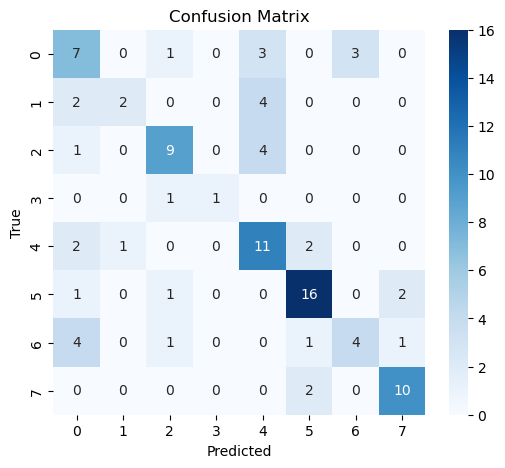

In [ ]:
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

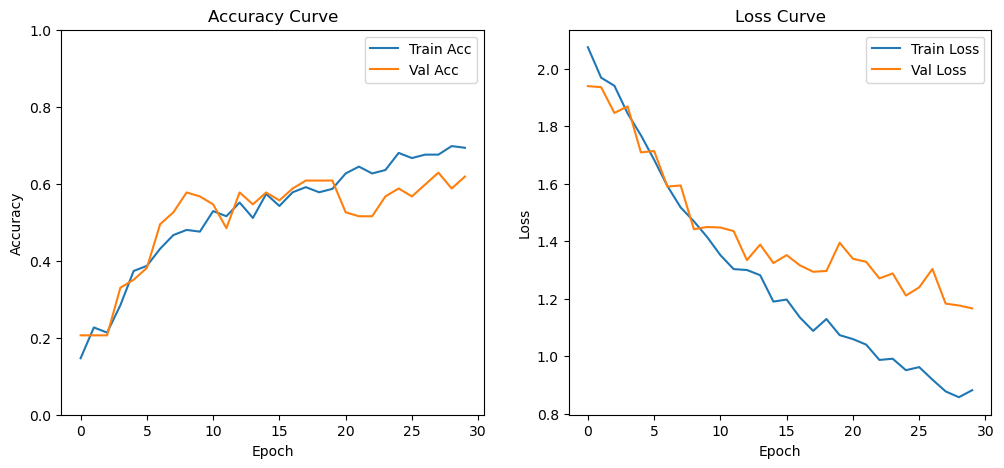

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_acc_history, label="Train Acc")
plt.plot(val_acc_history, label="Val Acc")
plt.ylim(0, 1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()